# Credit Scoring Model - German Credit Data

**Mục tiêu:** Xây dựng mô hình dự báo xác suất khách hàng vỡ nợ (default) từ bộ dữ liệu German Credit Data, sử dụng phương pháp WOE/IV và Logistic Regression, sau đó quy đổi thành scorecard theo điểm số và xác định ngưỡng cutoff duyệt hồ sơ.

## 1. Import thư viện

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import seaborn as sns

## 2. Đọc dữ liệu và ánh xạ các biến phân loại

Đọc file dữ liệu gốc và ánh xạ các mã biến (A11, A12, ...) sang nhãn dễ đọc. Biến **target** được chuyển về dạng nhị phân: **0 = khách hàng tốt**, **1 = khách hàng xấu (default)**.

In [2]:


columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents', 'telephone',
    'foreign_worker', 'target'
]

df = pd.read_csv(r'D:\My Project\Default of Credit Card Clients\statlog+german+credit+data\german.data', sep=' ', header=None, names=columns)


checking_account_map = {
    'A11': '< 0 DM',
    'A12': '0 - 200 DM',
    'A13': '>= 200 DM / salary assignment',
    'A14': 'no checking account'
}

credit_history_map = {
    'A30': 'no credits/all paid duly',
    'A31': 'all credits at this bank paid duly',
    'A32': 'existing credits paid duly till now',
    'A33': 'delay in paying in the past',
    'A34': 'critical account/other credits existing'
}

purpose_map = {
    'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment',
    'A43': 'radio/tv', 'A44': 'domestic appliances', 'A45': 'repairs',
    'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
    'A49': 'business', 'A410': 'others'
}

savings_account_map = {
    'A61': '< 100 DM',
    'A62': '100 - 500 DM',
    'A63': '500 - 1000 DM',
    'A64': '>= 1000 DM',
    'A65': 'unknown/no savings account'
}

employment_since_map = {
    'A71': 'unemployed',
    'A72': '< 1 year',
    'A73': '1 - 4 years',
    'A74': '4 - 7 years',
    'A75': '>= 7 years'
}

personal_status_sex_map = {
    'A91': 'male: divorced/separated',
    'A92': 'female: divorced/separated/married',
    'A93': 'male: single',
    'A94': 'male: married/widowed',
    'A95': 'female: single'
}

other_debtors_map = {
    'A101': 'none',
    'A102': 'co-applicant',
    'A103': 'guarantor'
}

property_map = {
    'A121': 'real estate',
    'A122': 'building society savings/life insurance',
    'A123': 'car or other',
    'A124': 'unknown/no property'
}

other_installment_plans_map = {
    'A141': 'bank',
    'A142': 'stores',
    'A143': 'none'
}

housing_map = {
    'A151': 'rent',
    'A152': 'own',
    'A153': 'for free'
}

job_map = {
    'A171': 'unemployed/unskilled non-resident',
    'A172': 'unskilled resident',
    'A173': 'skilled employee/official',
    'A174': 'management/self-employed/highly qualified'
}

telephone_map = {
    'A191': 'none',
    'A192': 'yes, registered'
}

foreign_worker_map = {
    'A201': 'yes',
    'A202': 'no'
}

target_map = {
    1: 0,
    2: 1
}


mapping_dict = {
    'checking_account': checking_account_map,
    'credit_history': credit_history_map,
    'purpose': purpose_map,
    'savings_account': savings_account_map,
    'employment_since': employment_since_map,
    'personal_status_sex': personal_status_sex_map,
    'other_debtors': other_debtors_map,
    'property': property_map,
    'other_installment_plans': other_installment_plans_map,
    'housing': housing_map,
    'job': job_map,
    'telephone': telephone_map,
    'foreign_worker': foreign_worker_map,
    'target': target_map
}

for col, mapping in mapping_dict.items():
    df[col] = df[col].map(mapping)


## 3. EDA

In [3]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical account/other credits existing,radio/tv,1169,unknown/no savings account,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee/official,1,"yes, registered",yes,0
1,0 - 200 DM,48,existing credits paid duly till now,radio/tv,5951,< 100 DM,1 - 4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,1
2,no checking account,12,critical account/other credits existing,education,2096,< 100 DM,4 - 7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4 - 7 years,2,male: single,guarantor,...,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,0
4,< 0 DM,24,delay in paying in the past,car (new),4870,< 100 DM,1 - 4 years,3,male: single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,1


In [4]:
df.isnull().sum()

checking_account           0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
target                     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [6]:
df.shape

(1000, 21)

In [7]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [8]:
df['target'].value_counts()

target
0    700
1    300
Name: count, dtype: int64

## 4. Phân phối các biến số và biến phân loại

Khảo sát phân phối của các biến số, kiểm tra giá trị ngoại lai (outlier) bằng biểu đồ boxplot, đồng thời phân tích tần suất của các biến phân loại và tỷ lệ **default** trung bình theo từng nhóm.

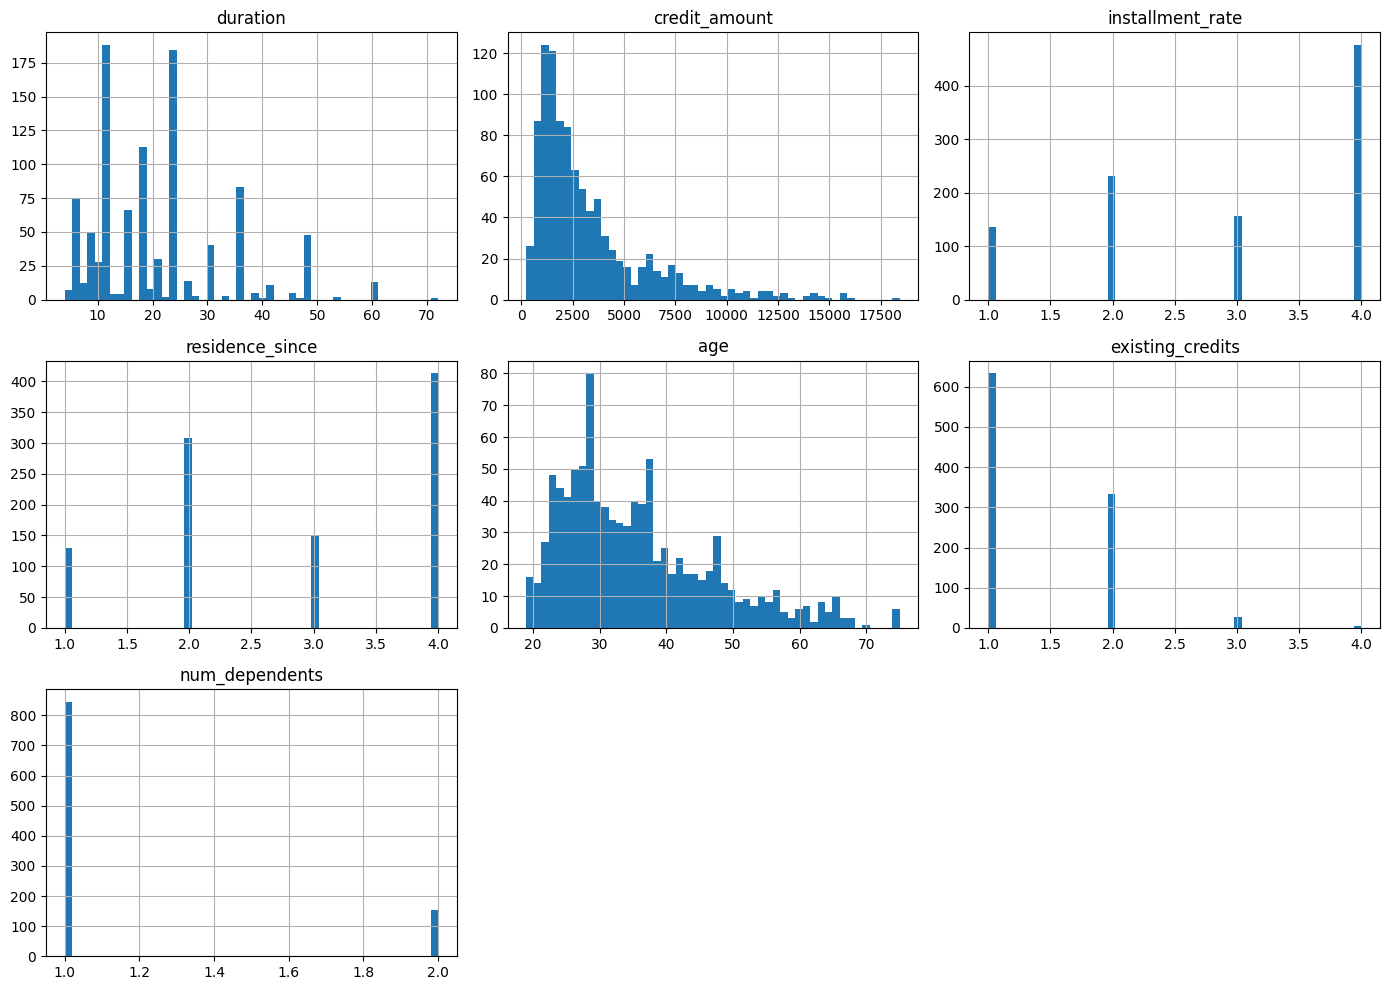

In [9]:
num_cols = ['duration','credit_amount','installment_rate','residence_since','age','existing_credits','num_dependents']
df[num_cols].hist(figsize=(14,10), bins=50)
plt.tight_layout()
plt.show()

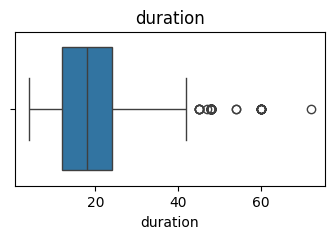

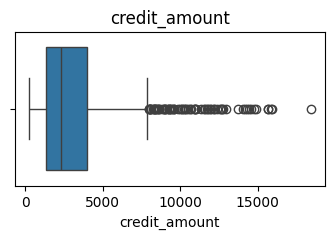

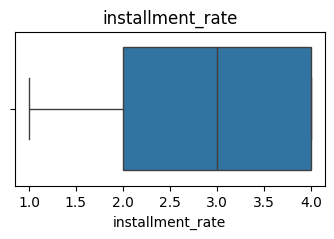

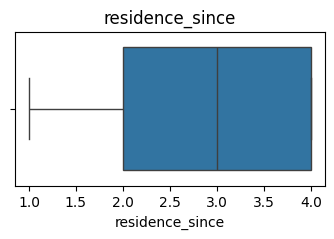

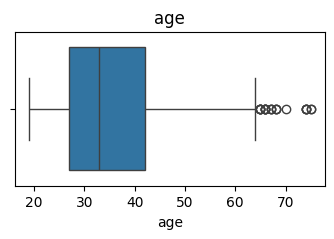

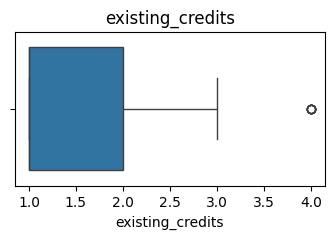

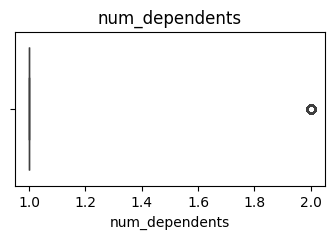

In [10]:
for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

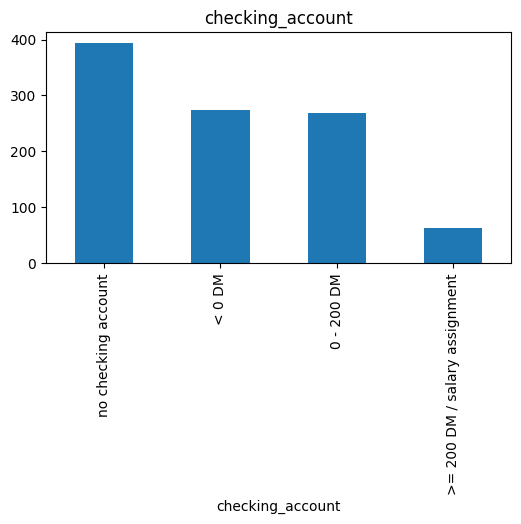

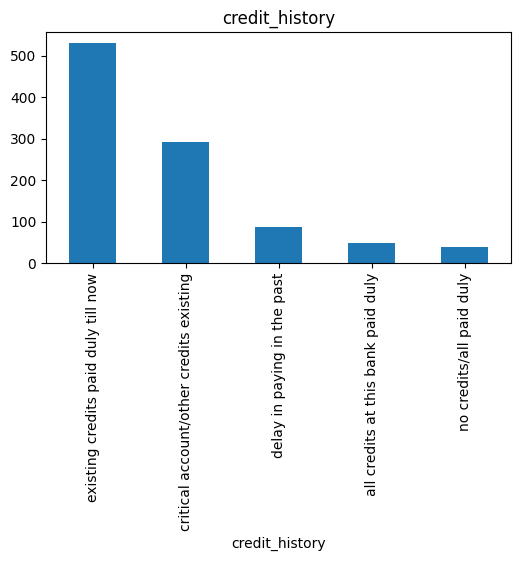

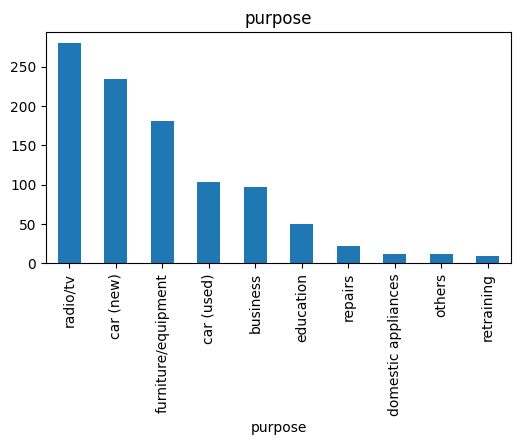

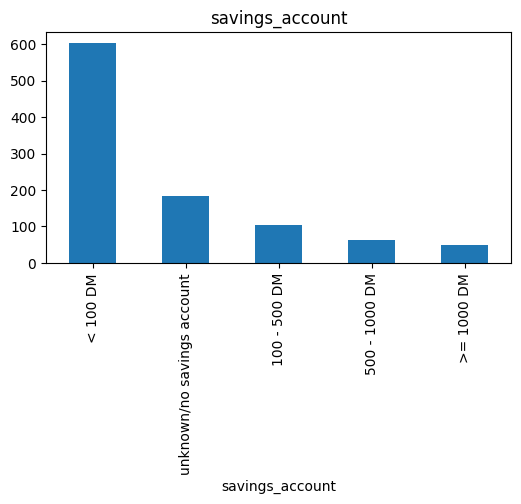

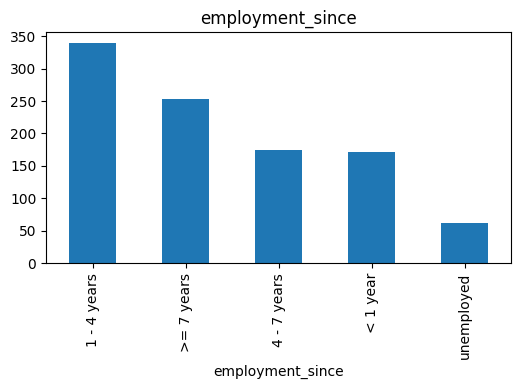

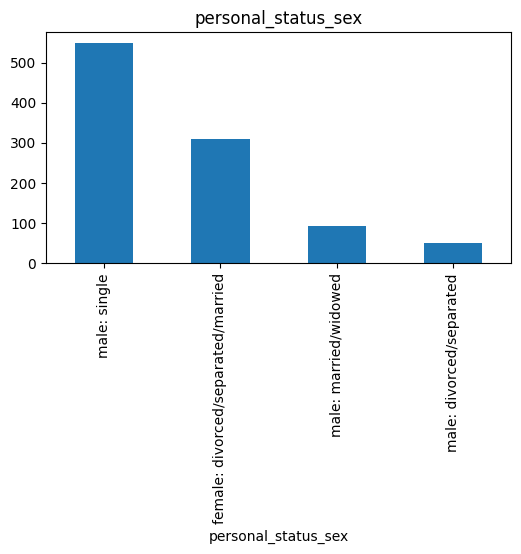

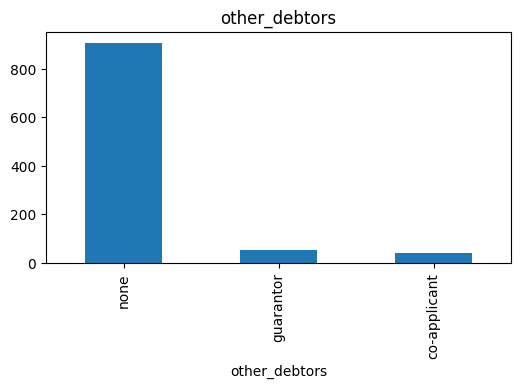

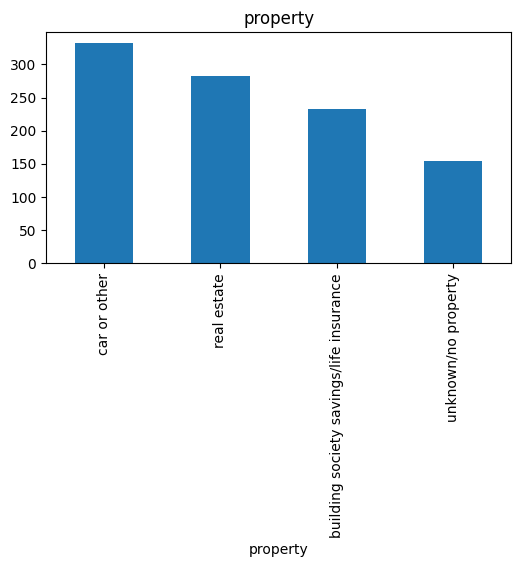

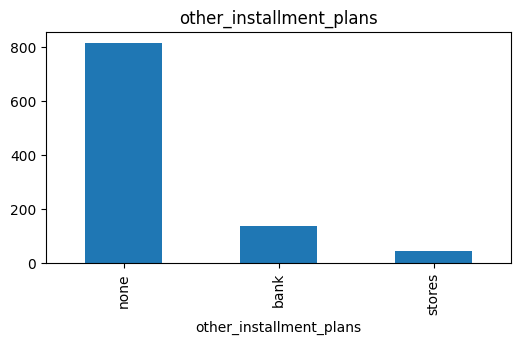

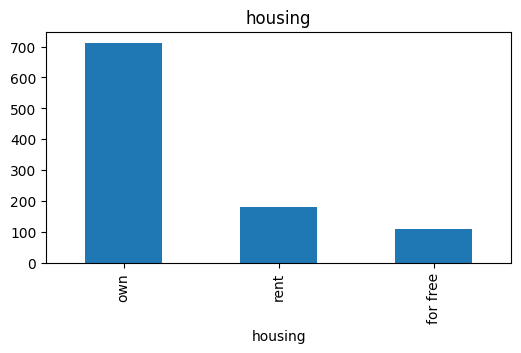

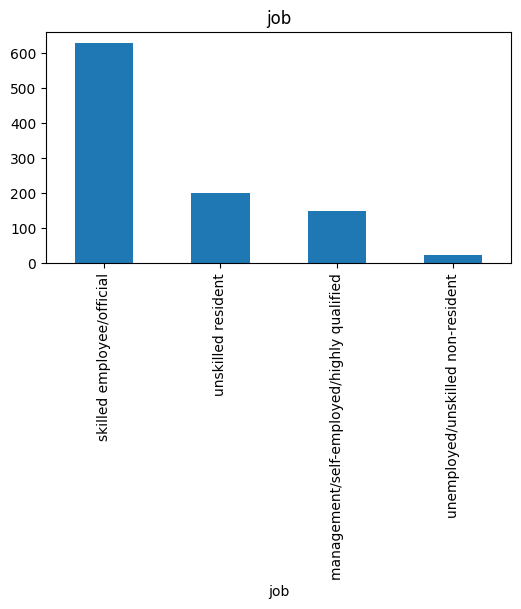

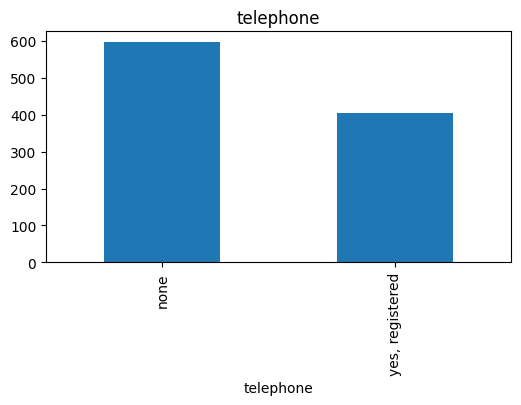

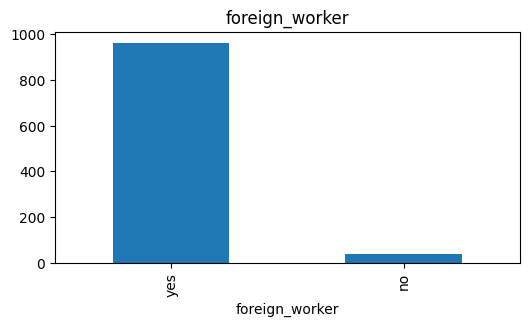

In [11]:
cat_cols = ['checking_account','credit_history','purpose','savings_account',
            'employment_since','personal_status_sex','other_debtors','property',
            'other_installment_plans','housing','job','telephone','foreign_worker']

for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [12]:
for col in cat_cols:
    print(df.groupby(col)['target'].mean().sort_values())

checking_account
no checking account              0.116751
>= 200 DM / salary assignment    0.222222
0 - 200 DM                       0.390335
< 0 DM                           0.492701
Name: target, dtype: float64
credit_history
critical account/other credits existing    0.170648
delay in paying in the past                0.318182
existing credits paid duly till now        0.318868
all credits at this bank paid duly         0.571429
no credits/all paid duly                   0.625000
Name: target, dtype: float64
purpose
retraining             0.111111
car (used)             0.165049
radio/tv               0.221429
furniture/equipment    0.320442
domestic appliances    0.333333
business               0.350515
repairs                0.363636
car (new)              0.380342
others                 0.416667
education              0.440000
Name: target, dtype: float64
savings_account
>= 1000 DM                    0.125000
500 - 1000 DM                 0.174603
unknown/no savings account    0

## 5. Tương quan giữa các biến số

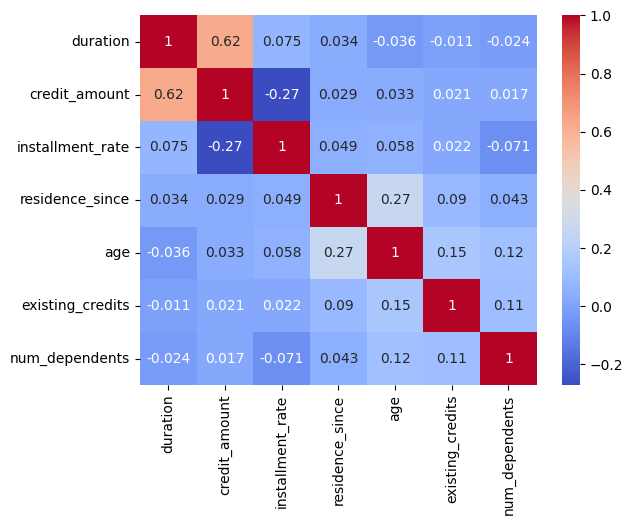

In [13]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

## 6. Chia tập train/test

Chia dữ liệu thành hai tập **train** và **test** theo tỷ lệ **70/30**, đồng thời sử dụng **stratify** để giữ nguyên tỷ lệ của biến **target** giữa hai tập dữ liệu.

In [14]:
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['target'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print(train_df['target'].value_counts(normalize=True))
print(test_df['target'].value_counts(normalize=True))

Train shape: (700, 21)
Test shape : (300, 21)
target
0    0.7
1    0.3
Name: proportion, dtype: float64
target
0    0.7
1    0.3
Name: proportion, dtype: float64


## 7. Hàm tính WOE và IV

**WOE (Weight of Evidence)** đo mức độ phân tách giữa hai nhóm **good** và **bad** trong từng bin, còn **IV (Information Value)** đo sức mạnh dự báo tổng thể của một biến đối với biến mục tiêu (**target**).

In [15]:
def woe_iv_table(df, group_col, target_col='target'):
    total_event = df[target_col].sum()
    total_non_event = (df[target_col] == 0).sum()

    grouped = df.groupby(group_col, observed=True)[target_col].agg(N='count', Events='sum')
    grouped['Non_Events'] = grouped['N'] - grouped['Events']

    grouped['Events_adj'] = grouped['Events'].replace(0, 0.5)
    grouped['Non_Events_adj'] = grouped['Non_Events'].replace(0, 0.5)

    grouped['pct_event'] = grouped['Events_adj'] / total_event
    grouped['pct_non_event'] = grouped['Non_Events_adj'] / total_non_event

    grouped['WOE'] = np.log(grouped['pct_non_event'] / grouped['pct_event'])
    grouped['IV_bin'] = (grouped['pct_non_event'] - grouped['pct_event']) * grouped['WOE']

    return grouped, grouped['IV_bin'].sum()

## 8. Tính WOE/IV cho biến `duration` (thử nhiều cách chia bin)

Thử nhiều phương pháp chia bin cho biến **`duration`**, tính **WOE** và **IV** tương ứng, sau đó so sánh kết quả để lựa chọn cách chia bin phù hợp nhất, đảm bảo khả năng phân tách tốt và xu hướng WOE hợp lý.

In [16]:
train_df['duration_bin'] = pd.qcut(train_df['duration'], q=5, duplicates='drop')
duration_table, duration_iv = woe_iv_table(train_df, 'duration_bin')
print(duration_table[['N','Events','Non_Events','WOE','IV_bin']].round(4))
print("Total IV:", round(duration_iv, 4))

                 N  Events  Non_Events     WOE  IV_bin
duration_bin                                          
(3.999, 12.0]  260      54         206  0.4916  0.0803
(12.0, 15.0]    49      10          39  0.5137  0.0164
(15.0, 24.0]   230      79         151 -0.1995  0.0136
(24.0, 30.0]    40      13          27 -0.1164  0.0008
(30.0, 60.0]   121      54          67 -0.6316  0.0760
Total IV: 0.1871


In [17]:
train_df['duration_bin'] = pd.cut(train_df['duration'], bins =[3.999,15,30,72])
duration_table, duration_iv = woe_iv_table(train_df, 'duration_bin')
print(duration_table[['N','Events','Non_Events','WOE','IV_bin']].round(4))
print("Total IV:", round(duration_iv, 4))

                 N  Events  Non_Events     WOE  IV_bin
duration_bin                                          
(3.999, 15.0]  309      64         245  0.4951  0.0967
(15.0, 30.0]   270      92         178 -0.1873  0.0140
(30.0, 72.0]   121      54          67 -0.6316  0.0760
Total IV: 0.1867


## 9. Tính WOE/IV cho các biến số còn lại

Áp dụng phương pháp chia bin phù hợp để tính **WOE** và **IV** cho các biến số còn lại, sau đó đánh giá sức mạnh dự báo của từng biến và kiểm tra tính hợp lý của xu hướng WOE trước khi đưa vào mô hình.

In [18]:
cols = [
    'credit_amount',
    'installment_rate',
    'residence_since',
    'age',
    'existing_credits',
    'num_dependents'
]

for col in cols:
    train_df[f'{col}_bin'] = pd.qcut(train_df[col], q=5, duplicates='drop')
    table, iv = woe_iv_table(train_df, f'{col}_bin')

    print(f'\n===== {col} =====')
    print(table[['N', 'Events', 'Non_Events', 'WOE', 'IV_bin']].round(4))
    print("Total IV:", round(iv, 4))


===== credit_amount =====
                     N  Events  Non_Events     WOE  IV_bin
credit_amount_bin                                         
(337.999, 1248.2]  140      44          96 -0.0671  0.0009
(1248.2, 1919.0]   141      33         108  0.3383  0.0214
(1919.0, 2788.8]   139      41          98  0.0241  0.0001
(2788.8, 4738.0]   140      37         103  0.1765  0.0060
(4738.0, 15945.0]  140      55          85 -0.4120  0.0364
Total IV: 0.0649

===== installment_rate =====
                        N  Events  Non_Events     WOE  IV_bin
installment_rate_bin                                         
(0.999, 2.0]          266      67         199  0.2413  0.0210
(2.0, 3.0]            112      36          76 -0.1001  0.0016
(3.0, 4.0]            322     107         215 -0.1495  0.0106
Total IV: 0.0332

===== residence_since =====
                       N  Events  Non_Events     WOE  IV_bin
residence_since_bin                                         
(0.999, 2.0]         311      94   

In [19]:
train_df['credit_amount_bin'] = pd.cut(train_df['credit_amount'], bins=[249.999,1906.8,18424.0])

credit_amount_table, credit_amount_iv = woe_iv_table(train_df, 'credit_amount_bin')

print(credit_amount_table[['N', 'Events', 'Non_Events', 'WOE', 'IV_bin']].round(4))
print("Total IV:", round(credit_amount_iv, 4))

                     N  Events  Non_Events     WOE  IV_bin
credit_amount_bin                                         
(249.999, 1906.8]  278      75         203  0.1484  0.0085
(1906.8, 18424.0]  422     135         287 -0.0931  0.0053
Total IV: 0.0138


In [20]:
train_df['age_bin'] = pd.cut(train_df['age'], bins=[18.999,30.0,36.0,75.0])

age_table, age_iv = woe_iv_table(train_df, 'age_bin')

print(age_table[['N', 'Events', 'Non_Events', 'WOE', 'IV_bin']].round(4))
print("Total IV:", round(age_iv, 4))

                  N  Events  Non_Events     WOE  IV_bin
age_bin                                                
(18.999, 30.0]  280      98         182 -0.2283  0.0217
(30.0, 36.0]    166      45         121  0.1418  0.0046
(36.0, 75.0]    254      67         187  0.1791  0.0112
Total IV: 0.0376


## 10. Tính WOE/IV cho các biến phân loại



In [21]:
cols = [
    'checking_account',
    'credit_history',
    'purpose',
    'savings_account',
    'employment_since',
    'personal_status_sex',
    'other_debtors',
    'property',
    'other_installment_plans',
    'housing',
    'job',
    'telephone',
    'foreign_worker'
]

for col in cols:
    table, iv = woe_iv_table(train_df, f'{col}')

    print(f'\n===== {col} =====')
    print(table[['N', 'Events', 'Non_Events', 'WOE', 'IV_bin']].round(4))
    print("Total IV:", round(iv, 4))



===== checking_account =====
                                 N  Events  Non_Events     WOE  IV_bin
checking_account                                                      
0 - 200 DM                     188      74         114 -0.4152  0.0497
< 0 DM                         192      92         100 -0.7639  0.1788
>= 200 DM / salary assignment   44      12          32  0.1335  0.0011
no checking account            276      32         244  1.1841  0.4092
Total IV: 0.6388

===== credit_history =====
                                           N  Events  Non_Events     WOE  \
credit_history                                                             
all credits at this bank paid duly        38      21          17 -1.0586   
critical account/other credits existing  205      36         169  0.6991   
delay in paying in the past               67      22          45 -0.1317   
existing credits paid duly till now      362     115         247 -0.0828   
no credits/all paid duly                  2

## 11. Gom nhóm một số biến phân loại

Gộp các mức có giá trị **WOE** gần nhau hoặc có số lượng quan sát ít nhằm tăng độ ổn định của các bin, giảm nguy cơ **overfitting** và cải thiện khả năng tổng quát hóa của mô hình.

In [22]:
train_df['credit_history_bin'] = train_df['credit_history'].replace({
    'all credits at this bank paid duly': 'no_credit_or_paid_this_bank',
    'no credits/all paid duly': 'no_credit_or_paid_this_bank',
    'delay in paying in the past': 'existing_paid_or_delay',
    'existing credits paid duly till now': 'existing_paid_or_delay'
})

ch_table, ch_iv = woe_iv_table(train_df, 'credit_history_bin')
print(ch_table[['N','Events','Non_Events','WOE','IV_bin']].round(4))
print("Total IV:", round(ch_iv, 4))

train_df['employment_since_bin'] = train_df['employment_since'].replace({
    '>= 7 years': 'gte_4_years',
    '4 - 7 years': 'gte_4_years',
    'unemployed': 'unemployed_or_lt1yr',
    '< 1 year': 'unemployed_or_lt1yr'
})

emp_table, emp_iv = woe_iv_table(train_df, 'employment_since_bin')
print(emp_table[['N','Events','Non_Events','WOE','IV_bin']].round(4))
print("Total IV:", round(emp_iv, 4))

                                           N  Events  Non_Events     WOE  \
credit_history_bin                                                         
critical account/other credits existing  205      36         169  0.6991   
existing_paid_or_delay                   429     137         292 -0.0905   
no_credit_or_paid_this_bank               66      37          29 -1.0909   

                                         IV_bin  
credit_history_bin                               
critical account/other credits existing  0.1213  
existing_paid_or_delay                   0.0051  
no_credit_or_paid_this_bank              0.1276  
Total IV: 0.254
                        N  Events  Non_Events     WOE  IV_bin
employment_since_bin                                         
1 - 4 years           246      70         176  0.0747  0.0019
gte_4_years           297      71         226  0.3106  0.0382
unemployed_or_lt1yr   157      69          88 -0.6041  0.0900
Total IV: 0.1302


In [23]:
train_df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,target,duration_bin,credit_amount_bin,installment_rate_bin,residence_since_bin,age_bin,existing_credits_bin,num_dependents_bin,credit_history_bin,employment_since_bin
0,0 - 200 DM,12,existing credits paid duly till now,car (new),1295,< 100 DM,< 1 year,3,female: divorced/separated/married,none,...,1,"(3.999, 15.0]","(249.999, 1906.8]","(2.0, 3.0]","(0.999, 2.0]","(18.999, 30.0]","(0.999, 2.0]","(0.999, 2.0]",existing_paid_or_delay,unemployed_or_lt1yr
1,no checking account,18,existing credits paid duly till now,business,1568,100 - 500 DM,1 - 4 years,3,female: divorced/separated/married,none,...,0,"(15.0, 30.0]","(249.999, 1906.8]","(2.0, 3.0]","(3.0, 4.0]","(18.999, 30.0]","(0.999, 2.0]","(0.999, 2.0]",existing_paid_or_delay,1 - 4 years
2,no checking account,18,no credits/all paid duly,business,4165,< 100 DM,1 - 4 years,2,male: single,none,...,1,"(15.0, 30.0]","(1906.8, 18424.0]","(0.999, 2.0]","(0.999, 2.0]","(30.0, 36.0]","(0.999, 2.0]","(0.999, 2.0]",no_credit_or_paid_this_bank,1 - 4 years
3,0 - 200 DM,24,existing credits paid duly till now,radio/tv,1967,< 100 DM,>= 7 years,4,female: divorced/separated/married,none,...,0,"(15.0, 30.0]","(1906.8, 18424.0]","(3.0, 4.0]","(3.0, 4.0]","(18.999, 30.0]","(0.999, 2.0]","(0.999, 2.0]",existing_paid_or_delay,gte_4_years
4,no checking account,11,critical account/other credits existing,car (new),7228,< 100 DM,1 - 4 years,1,male: single,none,...,0,"(3.999, 15.0]","(1906.8, 18424.0]","(0.999, 2.0]","(3.0, 4.0]","(36.0, 75.0]","(0.999, 2.0]","(0.999, 2.0]",critical account/other credits existing,1 - 4 years


## 12. Chọn biến đưa vào mô hình

Dựa trên bảng **IV** tổng hợp ở các bước trước, lựa chọn các biến có **IV** ở mức trung bình đến khá (thường trong khoảng **0.02–0.5**). Loại bỏ các biến có **IV** quá thấp vì khả năng dự báo kém, đồng thời thận trọng với các biến có **IV** quá cao vì có thể là dấu hiệu của **data leakage**.

Sau quá trình đánh giá, bốn biến được chọn để xây dựng mô hình gồm: **`duration_bin`**, **`credit_history_bin`**, **`checking_account`** và **`savings_account`**.

In [24]:
selected_cols = ['duration_bin', 'credit_history_bin', 'checking_account', 'savings_account']

df_final = train_df[selected_cols + ['target']].copy()

woe_maps = {} 

for col in selected_cols:
    table, iv = woe_iv_table(train_df, col)
    woe_map = table['WOE'].to_dict()
    woe_maps[col] = woe_map

    df_final[f'{col}_woe'] = df_final[col].map(woe_map)

    print(f'{col}: IV = {round(iv, 4)}, đã map {df_final[f"{col}_woe"].isnull().sum()} giá trị null')

woe_cols = [f'{col}_woe' for col in selected_cols]
df_final = df_final[woe_cols + ['target']]

df_final.head()

duration_bin: IV = 0.1867, đã map 0 giá trị null
credit_history_bin: IV = 0.254, đã map 0 giá trị null
checking_account: IV = 0.6388, đã map 0 giá trị null
savings_account: IV = 0.2335, đã map 0 giá trị null


,duration_bin_woe,credit_history_bin_woe,checking_account_woe,savings_account_woe,target
0,0.495077,-0.090525,-0.415165,-0.301787,1
1,-0.187303,-0.090525,1.184134,-0.098061,0
2,-0.187303,-1.090920,1.184134,-0.301787,1
3,-0.187303,-0.090525,-0.415165,-0.301787,0
4,0.495077,0.699082,1.184134,-0.301787,0


## 13. Áp dụng WOE đã tính từ tập train sang tập test

Sử dụng các giá trị **WOE** được tính trên tập **train** để biến đổi các biến tương ứng trong tập **test**. Việc này giúp đảm bảo không xảy ra **data leakage**, đồng thời giữ tính nhất quán giữa quá trình huấn luyện và đánh giá mô hình.

In [25]:

test_df['duration_bin'] = pd.cut(test_df['duration'], bins=[3.999, 15, 30, 72])

test_df['credit_history_bin'] = test_df['credit_history'].replace({
    'all credits at this bank paid duly': 'no_credit_or_paid_this_bank',
    'no credits/all paid duly': 'no_credit_or_paid_this_bank',
    'delay in paying in the past': 'existing_paid_or_delay',
    'existing credits paid duly till now': 'existing_paid_or_delay'
})


df_test_final = test_df[selected_cols + ['target']].copy()

for col in selected_cols:
    df_test_final[f'{col}_woe'] = df_test_final[col].map(woe_maps[col])
    n_null = df_test_final[f'{col}_woe'].isnull().sum()
    print(f'{col}: đã map {n_null} giá trị null trên test'
          + (' (bin/category chỉ xuất hiện ở test, không có trong train)' if n_null else ''))

woe_cols = [f'{col}_woe' for col in selected_cols]
df_test_final = df_test_final[woe_cols + ['target']]

df_test_final.head()

duration_bin: đã map 0 giá trị null trên test
credit_history_bin: đã map 0 giá trị null trên test
checking_account: đã map 0 giá trị null trên test
savings_account: đã map 0 giá trị null trên test


,duration_bin_woe,credit_history_bin_woe,checking_account_woe,savings_account_woe,target
0,-0.631589,0.699082,1.184134,0.862224,0
1,0.495077,0.699082,-0.415165,-0.301787,0
2,-0.631589,-0.090525,0.133531,-0.301787,0
3,-0.187303,0.699082,1.184134,-0.301787,0
4,0.495077,-0.090525,-0.763916,-0.301787,0


## 14. Tạo tập X, y cho train và test

In [26]:
woe_cols = [f'{col}_woe' for col in selected_cols]

X_train = df_final[woe_cols]
y_train = df_final['target']

X_test = df_test_final[woe_cols]
y_test = df_test_final['target']

## 15. Kiểm định chéo (Cross Validation)

Trước khi huấn luyện mô hình cuối cùng, đánh giá độ ổn định và khả năng tổng quát hóa của bộ biến đã chọn bằng **StratifiedKFold 5-fold**. Trong mỗi lần chia dữ liệu, **WOE** được tính lại chỉ trên tập **train** của từng fold và sau đó áp dụng cho tập **validation**, nhằm tránh **data leakage** giữa các fold và đảm bảo kết quả đánh giá khách quan.

In [27]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def ks_statistic(y_true, y_proba):
    tmp = pd.DataFrame({'y': y_true.values, 'proba': y_proba}).sort_values('proba')
    tmp['cum_bad']  = (tmp['y'] == 1).cumsum() / (tmp['y'] == 1).sum()
    tmp['cum_good'] = (tmp['y'] == 0).cumsum() / (tmp['y'] == 0).sum()
    return np.max(np.abs(tmp['cum_bad'] - tmp['cum_good']))

fold_selected_cols = ['duration_bin', 'credit_history_bin', 'checking_account', 'savings_account']
credit_history_regroup = {
    'all credits at this bank paid duly': 'no_credit_or_paid_this_bank',
    'no credits/all paid duly': 'no_credit_or_paid_this_bank',
    'delay in paying in the past': 'existing_paid_or_delay',
    'existing credits paid duly till now': 'existing_paid_or_delay'
}

auc_scores, ks_scores = [], []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(train_df, train_df['target']), start=1):
    fold_train = train_df.iloc[tr_idx].copy()
    fold_val   = train_df.iloc[val_idx].copy()

    fold_train['duration_bin'] = pd.cut(fold_train['duration'], bins=[3.999, 15, 30, 72])
    fold_val['duration_bin']   = pd.cut(fold_val['duration'],   bins=[3.999, 15, 30, 72])
    fold_train['credit_history_bin'] = fold_train['credit_history'].replace(credit_history_regroup)
    fold_val['credit_history_bin']   = fold_val['credit_history'].replace(credit_history_regroup)

    fold_woe_maps = {}
    for col in fold_selected_cols:
        table, iv = woe_iv_table(fold_train, col)
        fold_woe_maps[col] = table['WOE'].to_dict()

    X_tr = pd.DataFrame({
    f'{c}_woe': fold_train[c].map(fold_woe_maps[c]).astype(float)
    for c in fold_selected_cols
    }).fillna(0)

    X_val = pd.DataFrame({
        f'{c}_woe': fold_val[c].map(fold_woe_maps[c]).astype(float)
        for c in fold_selected_cols
    }).fillna(0)
    y_tr, y_val = fold_train['target'], fold_val['target']

    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    proba_val = model.predict_proba(X_val)[:, 1]

    auc_scores.append(roc_auc_score(y_val, proba_val))
    ks_scores.append(ks_statistic(y_val, proba_val))
    print(f'Fold {fold_idx}: AUC = {auc_scores[-1]:.4f}  |  KS = {ks_scores[-1]:.4f}')

print('\n--- Tổng kết ---')
print(f'AUC trung bình: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
print(f'KS  trung bình: {np.mean(ks_scores):.4f} ± {np.std(ks_scores):.4f}')

Fold 1: AUC = 0.7896  |  KS = 0.4490
Fold 2: AUC = 0.7829  |  KS = 0.4898
Fold 3: AUC = 0.7223  |  KS = 0.4082
Fold 4: AUC = 0.7298  |  KS = 0.4388
Fold 5: AUC = 0.7681  |  KS = 0.4898

--- Tổng kết ---
AUC trung bình: 0.7586 ± 0.0275
KS  trung bình: 0.4551 ± 0.0314


## 16. Kiểm tra đa cộng tuyến (VIF)

Kiểm tra **Variance Inflation Factor (VIF)** giữa các biến **WOE** đã chọn nhằm đánh giá mức độ đa cộng tuyến trước khi huấn luyện mô hình. Các biến có giá trị **VIF** cao sẽ được xem xét loại bỏ hoặc thay thế để đảm bảo mô hình **Logistic Regression** có hệ số ổn định và dễ diễn giải.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data[vif_data['feature'] != 'const'])

                  feature       VIF
1        duration_bin_woe  1.007062
2  credit_history_bin_woe  1.039013
3    checking_account_woe  1.109321
4     savings_account_woe  1.067030


## 17. Xây dựng mô hình Logistic Regression cuối cùng

In [29]:

logit = LogisticRegression()
logit.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'feature': woe_cols,
    'coefficient': logit.coef_[0]
})
print(coef_df)
print('Intercept:', logit.intercept_[0])

                  feature  coefficient
0        duration_bin_woe    -0.966004
1  credit_history_bin_woe    -0.803410
2    checking_account_woe    -0.828231
3     savings_account_woe    -0.775858
Intercept: -0.8452200694950484


## 18. Đánh giá 


In [30]:


proba_train = logit.predict_proba(X_train)[:, 1]
proba_test = logit.predict_proba(X_test)[:, 1]

auc_train = roc_auc_score(y_train, proba_train)
auc_test = roc_auc_score(y_test, proba_test)

print(f'AUC train: {auc_train:.4f}  |  Gini train: {2*auc_train-1:.4f}')
print(f'AUC test : {auc_test:.4f}  |  Gini test : {2*auc_test-1:.4f}')

AUC train: 0.7774  |  Gini train: 0.5548
AUC test : 0.7852  |  Gini test : 0.5704


In [31]:
print('KS train:', round(ks_statistic(y_train, proba_train), 4))
print('KS test :', round(ks_statistic(y_test, proba_test), 4))

KS train: 0.4599
KS test : 0.4952


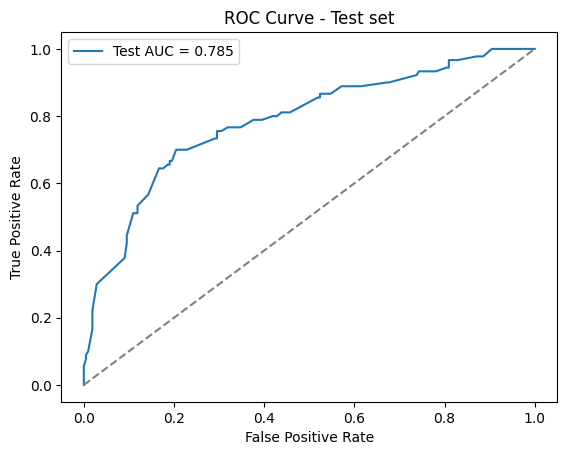

In [32]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.plot(fpr, tpr, label=f'Test AUC = {auc_test:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test set')
plt.legend()
plt.show()

## 19. Kiểm tra độ ổn định của mô hình bằng PSI

**Population Stability Index (PSI)** được sử dụng để đo mức độ thay đổi trong phân phối xác suất dự báo giữa tập **train** và tập **test**, từ đó đánh giá độ ổn định của mô hình trên các tập dữ liệu khác nhau.

Quy ước thường dùng:
- **PSI < 0.10:** Mô hình ổn định, phân phối gần như không thay đổi.
- **0.10 ≤ PSI < 0.25:** Có sự thay đổi nhẹ, cần tiếp tục theo dõi.
- **PSI ≥ 0.25:** Phân phối thay đổi đáng kể, cần xem xét lại mô hình hoặc dữ liệu đầu vào.

In [33]:
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    breakpoints = np.unique(breakpoints)
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_bins = pd.cut(expected, bins=breakpoints)
    actual_bins = pd.cut(actual, bins=breakpoints)

    expected_pct = expected_bins.value_counts(sort=False) / len(expected)
    actual_pct = actual_bins.value_counts(sort=False) / len(actual)

    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)

    psi_value = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi_value

psi_score = calculate_psi(pd.Series(proba_train), pd.Series(proba_test), buckets=10)
print(f'PSI (xac suat du bao, train vs test): {psi_score:.4f}')

if psi_score < 0.1:
    print('PSI < 0.1: mo hinh on dinh, khong co dau hieu lech du lieu dang ke.')
elif psi_score < 0.25:
    print('0.1 <= PSI < 0.25: co su thay doi nhe, can theo doi them.')
else:
    print('PSI >= 0.25: co dau hieu lech du lieu dang ke, can xem xet lai mo hinh.')


PSI (xac suat du bao, train vs test): 0.0209
PSI < 0.1: mo hinh on dinh, khong co dau hieu lech du lieu dang ke.


## 20. Xây dựng Scorecard

Quy đổi các hệ số của mô hình **Logistic Regression** kết hợp với giá trị **WOE** của từng bin thành điểm số (**score**) theo chuẩn **PDO (Points to Double the Odds)**. Scorecard thu được giúp diễn giải mức độ rủi ro của từng đặc trưng và tính tổng điểm tín dụng cho mỗi khách hàng một cách trực quan.

In [34]:

PDO = 20
Base_Score = 600
Base_Odds = 50   
Factor = PDO / np.log(2)
Offset = Base_Score - Factor * np.log(Base_Odds)

print(f'Factor = {Factor:.4f}, Offset = {Offset:.4f}')

n_vars = len(woe_cols)
intercept = logit.intercept_[0]

base_points = (Offset - Factor * intercept) / n_vars

scorecard_rows = []

for col, coef in zip(woe_cols, logit.coef_[0]):
    original_col = col.replace('_woe', '')
    woe_map = woe_maps[original_col]

    for bin_value, woe in woe_map.items():
        points = base_points - Factor * coef * woe
        scorecard_rows.append({
            'variable': original_col,
            'bin': bin_value,
            'WOE': round(woe, 4),
            'coef': round(coef, 4),
            'points': round(points, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)
print(scorecard_df)

Factor = 28.8539, Offset = 487.1229
              variable                                      bin     WOE  \
0         duration_bin                            (3.999, 15.0]  0.4951   
1         duration_bin                             (15.0, 30.0] -0.1873   
2         duration_bin                             (30.0, 72.0] -0.6316   
3   credit_history_bin  critical account/other credits existing  0.6991   
4   credit_history_bin                   existing_paid_or_delay -0.0905   
5   credit_history_bin              no_credit_or_paid_this_bank -1.0909   
6     checking_account                               0 - 200 DM -0.4152   
7     checking_account                                   < 0 DM -0.7639   
8     checking_account            >= 200 DM / salary assignment  0.1335   
9     checking_account                      no checking account  1.1841   
10     savings_account                             100 - 500 DM -0.0981   
11     savings_account                            500 - 1000 DM 

In [35]:
def calculate_score(row, selected_cols, woe_maps, scorecard_df, base_points):
    total = base_points * len(selected_cols)
    for col in selected_cols:
        bin_value = row[col]
        sub = scorecard_df[(scorecard_df['variable'] == col) & (scorecard_df['bin'] == bin_value)]
        if not sub.empty:
            total += sub['points'].values[0]
    return total

train_df['score'] = train_df.apply(lambda r: calculate_score(r, selected_cols, woe_maps, scorecard_df, base_points), axis=1)
test_df['score'] = test_df.apply(lambda r: calculate_score(r, selected_cols, woe_maps, scorecard_df, base_points), axis=1)

print('Diem tren tap train:')
print(train_df[['score', 'target']].groupby('target').describe())
print('\nDiem tren tap test:')
print(test_df[['score', 'target']].groupby('target').describe())


Diem tren tap train:
        score                                                                \
        count         mean        std         min          25%          50%   
target                                                                        
0       490.0  1039.656078  31.237202  963.510772  1016.810772  1038.760772   
1       210.0  1008.056010  26.919707  955.110772   990.710772  1005.010772   

                                  
                75%          max  
target                            
0       1060.910772  1104.010772  
1       1018.110772  1100.710772  

Diem tren tap test:
        score                                                                \
        count         mean        std         min          25%          50%   
target                                                                        
0       210.0  1040.035058  30.009112  967.510772  1018.110772  1037.310772   
1        90.0  1006.871883  29.606087  955.110772   986.710772   999.11

## 21. Xác định ngưỡng cutoff

Ngưỡng xác suất tối ưu được xác định bằng chỉ số **Youden's J** (giá trị lớn nhất của **TPR − FPR**) trên tập **test**. Ngưỡng này sau đó được quy đổi sang **điểm cutoff** theo công thức:

> **Score = Offset − Factor × logit(p)**

Trong đó, **p** là xác suất dự báo khách hàng **default**.

Các hồ sơ có **điểm ≥ cutoff** được đề xuất **Approve**, trong khi các hồ sơ có **điểm < cutoff** được đề xuất **Reject**.

In [36]:
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, proba_test)
youden_j = tpr_test - fpr_test
best_idx = np.argmax(youden_j)
best_threshold = thresholds_test[best_idx]

print(f'Nguong xac suat toi uu (Youden J): {best_threshold:.4f}')
print(f'Tai nguong nay: TPR = {tpr_test[best_idx]:.4f}, FPR = {fpr_test[best_idx]:.4f}')

cutoff_score = Offset - Factor * np.log(best_threshold / (1 - best_threshold))
print(f'Diem cutoff tuong ung: {cutoff_score:.1f}')

test_df['decision'] = np.where(test_df['score'] >= cutoff_score, 'Approve', 'Reject')

decision_summary = test_df.groupby('decision')['target'].agg(N='count', Bad_rate='mean')
print('\nKet qua duyet/tu choi tren tap test:')
print(decision_summary)


Nguong xac suat toi uu (Youden J): 0.3480
Tai nguong nay: TPR = 0.7000, FPR = 0.2048
Diem cutoff tuong ung: 505.2

Ket qua duyet/tu choi tren tap test:
            N  Bad_rate
decision               
Approve   300       0.3


## 22. Kết luận

### Kết quả chính

- Bộ biến cuối cùng được đưa vào mô hình gồm: **`duration`**, **`credit_history`**, **`checking_account`** và **`savings_account`** (đã được chuyển đổi sang dạng **WOE**). Các biến này đã được đánh giá thông qua **IV**, **VIF** và kiểm định **5-fold Cross Validation** trước khi huấn luyện mô hình chính thức.
- Hiệu năng mô hình được đánh giá bằng các chỉ số **AUC**, **Gini** và **KS** trên cả tập **train** và **test**. Trong bài toán **Credit Scoring**, mô hình thường được xem là đạt yêu cầu khi **AUC > 0.7** và **KS > 0.3**.
- Chỉ số **Population Stability Index (PSI)** giữa tập **train** và **test** được sử dụng để đánh giá mức độ ổn định của mô hình khi áp dụng trên dữ liệu mới.
- **Scorecard** giúp quy đổi mô hình **Logistic Regression** thành hệ thống điểm số dễ diễn giải và triển khai trong quy trình xét duyệt tín dụng. Ngưỡng **cutoff** được xác định dựa trên chỉ số **Youden's J**, giúp cân bằng giữa tỷ lệ phê duyệt đúng và tỷ lệ từ chối đúng.

### Hạn chế và hướng cải thiện


- Quá trình **binning** hiện được thực hiện thủ công dựa trên phân phối dữ liệu và giá trị **WOE**. Trong tương lai có thể thử các phương pháp binning tối ưu như **OptBinning** để so sánh và cải thiện hiệu quả.
- Mô hình cuối cùng chỉ sử dụng bốn biến. Có thể thử nghiệm thêm các tổ hợp biến khác dựa trên **IV**, **VIF** hoặc các phương pháp lựa chọn đặc trưng để xem liệu **AUC** và **KS** có được cải thiện hay không.
- Ngưỡng **cutoff** hiện được lựa chọn theo **Youden's J**, mang tính tối ưu về mặt thống kê. Khi triển khai trong thực tế, nên kết hợp thêm các mục tiêu kinh doanh như tỷ lệ phê duyệt mong muốn, mức độ rủi ro chấp nhận được và chi phí sai phân loại để lựa chọn ngưỡng phù hợp hơn.